In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [ ]:
csv_path = Path(r"C:\Users\user\Desktop\div\data\files\housing.csv")
df = pd.read_csv(csv_path)
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [ ]:
outliers1 = df['median_house_value'] == df['median_house_value'].max()
outliers2 = df['housing_median_age'] == df['housing_median_age'].max()
outliers = outliers1 | outliers2

df = df.loc[~outliers, :].copy()
print(df.shape)
df.head(3)

(18572, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY


In [ ]:
X = df.drop('median_house_value', axis='columns')
y = df['median_house_value']

In [ ]:
X['income_cat'] = pd.cut(
    X['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
    )

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=X['income_cat'],
    test_size=0.2
    )

X_train.shape, X_test.shape

((14857, 10), (3715, 10))

In [ ]:
X_train.drop('income_cat', axis='columns', inplace=True)
X_test.drop('income_cat', axis='columns', inplace=True)

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10):
        self.n_clusters = n_clusters

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(self.n_clusters)
        self.kmeans_.fit(X)
        return self  

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=1).round(3)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

cat_cols = ['ocean_proximity']
log_cols = [
    'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income'
    ]

cat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])
log_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, inverse_func=np.expm1, feature_names_out='one-to-one')),
    ('scl', StandardScaler())
])

def ratio_func(arr_2d):
    return arr_2d[:, [0]] / arr_2d[:, [1]]
def ratio_feature_names(*args, **kwargs):
    return ['ratio']

rat_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('newcol', FunctionTransformer(ratio_func, feature_names_out=ratio_feature_names)),
    ('scl', StandardScaler())
])
cluster_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('cluster', ClusterSimilarity(n_clusters=10))
])
num_pipeline = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler())
])

preprocessing = ColumnTransformer(
    transformers=[
        ('CAT', cat_pipeline, cat_cols),
        ('LOG', log_pipeline, log_cols),
        ('RAT_b/r', rat_pipeline, ['total_bedrooms', 'total_rooms']),
        ('RAT_r/h', rat_pipeline, ['total_rooms', 'households']),
        ('RAT_p/h', rat_pipeline, ['population', 'households']),
        ("GEO", cluster_pipeline, ["latitude", "longitude"]),
    ], remainder=num_pipeline
)

X_train_arr = preprocessing.fit_transform(X_train)
X_train_prepared = pd.DataFrame(X_train_arr, columns=preprocessing.get_feature_names_out())

X_test_arr = preprocessing.fit_transform(X_test)
X_test_prepared = pd.DataFrame(X_test_arr, columns=preprocessing.get_feature_names_out())

X_train_prepared

,CAT__ocean_proximity_<1H OCEAN,CAT__ocean_proximity_INLAND,CAT__ocean_proximity_ISLAND,CAT__ocean_proximity_NEAR BAY,CAT__ocean_proximity_NEAR OCEAN,LOG__total_rooms,LOG__total_bedrooms,LOG__population,LOG__households,LOG__median_income,RAT_b/r__ratio,RAT_r/h__ratio,RAT_p/h__ratio,GEO__Cluster 0 similarity,GEO__Cluster 1 similarity,GEO__Cluster 2 similarity,GEO__Cluster 3 similarity,GEO__Cluster 4 similarity,GEO__Cluster 5 similarity,GEO__Cluster 6 similarity,GEO__Cluster 7 similarity,GEO__Cluster 8 similarity,GEO__Cluster 9 similarity,remainder__housing_median_age
0,1.0,0.0,0.0,0.0,0.0,0.827720,0.231410,0.316217,0.393411,1.320583,-1.377924,0.756014,-0.033225,0.000,0.196,0.000,0.000,0.000,0.050,0.000,0.988,0.000,0.163,-0.086119
1,0.0,1.0,0.0,0.0,0.0,0.055021,0.598606,0.029953,0.495461,-0.873844,1.558783,-0.685595,-0.092348,0.009,0.000,0.640,0.493,0.405,0.000,0.000,0.000,0.000,0.000,-0.958707
2,1.0,0.0,0.0,0.0,0.0,-0.056766,-0.686316,-0.470774,-0.563708,1.804318,-1.382460,0.862961,-0.003962,0.000,0.271,0.000,0.000,0.000,0.076,0.000,0.997,0.000,0.166,-0.958707
3,1.0,0.0,0.0,0.0,0.0,-0.869925,-0.441389,0.261025,-0.412945,-0.516757,1.261610,-0.733695,0.139035,0.000,0.667,0.000,0.000,0.000,0.998,0.000,0.080,0.053,0.004,1.920833
4,0.0,0.0,0.0,1.0,0.0,-0.070307,0.016782,-0.098885,0.005817,-0.017324,0.125545,-0.214177,-0.038913,0.000,0.000,0.619,0.128,0.954,0.000,0.000,0.000,0.000,0.000,1.397280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14852,0.0,0.0,0.0,0.0,1.0,0.051295,-0.012109,-0.367159,0.049478,0.460658,-0.268050,-0.089812,-0.086619,0.000,0.229,0.000,0.000,0.000,0.077,0.000,0.977,0.000,0.096,1.484539
14853,1.0,0.0,0.0,0.0,0.0,-1.066807,-1.360700,-1.154138,-1.262831,0.419303,-0.702200,0.185163,-0.002485,0.000,0.627,0.000,0.000,0.000,0.989,0.000,0.090,0.051,0.003,0.786468
14854,0.0,1.0,0.0,0.0,0.0,-0.451374,-0.812533,-0.641607,-0.715513,0.894401,-0.879934,0.338935,-0.008049,0.001,0.000,0.167,0.974,0.193,0.000,0.002,0.000,0.000,0.000,-1.045966
14855,0.0,1.0,0.0,0.0,0.0,1.183609,1.302559,0.797380,1.192528,-0.817543,0.091166,-0.055280,-0.081405,0.000,0.000,0.043,0.746,0.151,0.000,0.028,0.000,0.000,0.000,-0.958707


In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = Pipeline([
    ("cleaning", preprocessing), 
    ("linreg", LinearRegression())
    ])
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

In [ ]:
y_pred

array([ 90603.4117617 , 125653.97118557, 252620.21470775, ...,
       274796.44052157, 181197.99202705, 230997.94837707], shape=(3715,))

In [ ]:
y_test.to_numpy()

array([129200.,  96300., 204700., ..., 361000., 183300., 280000.],
      shape=(3715,))

# Regression metrics

### 1. Mean Absolute Error (MAE)

**Mathematical Formula:**
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**Definition:** The average of absolute differences between predicted and actual values.

**Characteristics:**
- Robust to outliers
- Interpretable (same units as target)
- Not differentiable at zero

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test.to_numpy(), y_pred)
mae

42764.09632338144

### 2. Mean Squared Error (MSE)

**Mathematical Formula:**
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Definition:** The average of squared differences between predicted and actual values.

**Characteristics:**
- Penalizes large errors more heavily
- Differentiable everywhere
- Sensitive to outliers


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test.to_numpy(), y_pred)
mse

3344977188.3979473

### 3. Root Mean Squared Error (RMSE)

**Mathematical Formula:**
$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} = \sqrt{\text{MSE}}$$

**Definition:** The square root of MSE, providing error in the same units as the target.

**Characteristics:**
- Same units as target variable
- More interpretable than MSE
- Still sensitive to outliers

In [ ]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test.to_numpy(), y_pred)
rmse

57835.7777538951


### 4. R² Score (Coefficient of Determination)

**Mathematical Formula:**
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$$

Where:
- $\text{SS}_{\text{res}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ (Residual Sum of Squares)
- $\text{SS}_{\text{tot}} = \sum_{i=1}^{n} (y_i - \bar{y})^2$ (Total Sum of Squares)
- $\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$ (Mean of actual values)

**Definition:** The proportion of variance in the dependent variable that is predictable from the independent variables.

**Interpretation:**
- R² = 1.0: Perfect fit
- R² = 0.0: Model predicts the mean as well as any model
- R² < 0: Model performs worse than predicting the mean

**Characteristics:**
- Scale-independent
- Can be negative
- Increases with more predictors (use Adjusted R² for multiple regression)


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test.to_numpy(), y_pred)
r2

0.6466759206452306

### 5. Adjusted R²

**Mathematical Formula:**
$$R^2_{\text{adj}} = 1 - (1 - R^2) \frac{n - 1}{n - p - 1}$$

Where:
- $n$ = number of observations
- $p$ = number of predictors

**Definition:** Adjusted R² that accounts for the number of predictors in the model.

In [ ]:
def adjusted_r2_score(y_true, y_pred, n_features):
    n = len(y_true)
    p = n_features
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

adj_r2 = adjusted_r2_score(y_test.to_numpy(), y_pred, n_features=X.shape[1])
adj_r2

0.645722021942869

### 6. Mean Absolute Percentage Error (MAPE)

**Mathematical Formula:**
$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

**Definition:** The average of absolute percentage errors.

**Characteristics:**
- Scale-independent (percentage)
- Undefined when actual values are zero
- Asymmetric (penalizes underestimates more)

In [ ]:
# def mean_absolute_percentage_error(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     return np.mean(np.abs((y_true - y_pred) / y_true))

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test.to_numpy(), y_pred)
mape

0.2694095114022185

### 7. Huber Loss

**Mathematical Formula:**
$$\text{Huber}(y, \hat{y}) = \begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| \leq \delta \\
\delta(|y - \hat{y}| - \frac{1}{2}\delta) & \text{otherwise}
\end{cases}$$

**Definition:** A loss function that is quadratic for small errors and linear for large errors, providing robustness to outliers.

In [ ]:
def huber_loss_np(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    abs_error = np.abs(error)
    # Calculate quadratic and linear components
    quadratic_loss = 0.5 * error**2
    linear_loss = delta * (abs_error - 0.5 * delta)
    
    # Use np.where to select the appropriate loss
    loss = np.where(abs_error <= delta, quadratic_loss, linear_loss)
    return np.mean(loss) # or np.sum(loss) or no reduction

huber_loss_np(y_test.to_numpy(), y_pred, delta=1.0)

np.float64(42763.59632338144)

## Classification Metrics

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
y_pred = lr_clf.predict(X_test)
y_pred

array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1,
       0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0])

In [ ]:
y_test

array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 2,
       0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0])

In [ ]:
y_pred[y_pred != y_test], y_test[y_pred != y_test]

(array([1]), array([2]))

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[16,  0,  0],
       [ 0,  8,  0],
       [ 0,  1, 13]])

For $n$ classes, the confusion matrix is an $n \times n$ matrix where element $(i, j)$ contains the count of instances with true class $i$ predicted as class $j$.

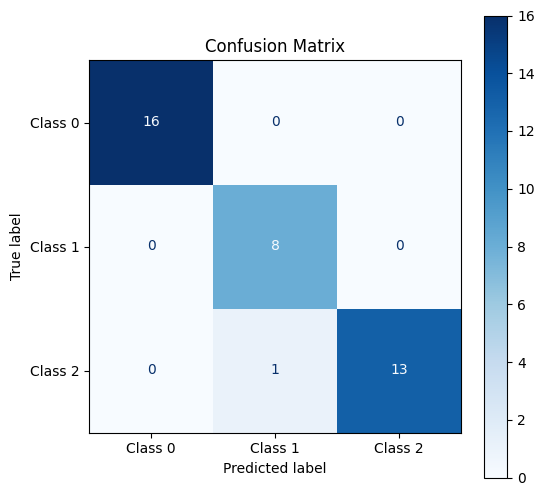

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1', 'Class 2'])
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

For multi-class classification with $n$ classes:
$$\text{Accuracy} = \frac{\sum_{i=1}^{n} \text{CM}_{i,i}}{N}$$

Where $\text{CM}_{i,i}$ is the diagonal element (correct predictions) for class $i$, and $N$ is the total number of instances.

**Definition:** The proportion of correctly classified instances out of all instances.

**Limitations:** Accuracy can be misleading for imbalanced datasets. For multi-class problems with class imbalance, consider using balanced accuracy or other metrics.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_multiclass = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy_multiclass:.4f}")

# Or manually from confusion matrix:
accuracy_from_cm = np.trace(cm) / np.sum(cm)


Accuracy: 0.9737


In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

Balanced Accuracy: 0.9762


### 3. Precision, Recall, and F1-Score

- True Positives (TP): The diagonal elements.
	- e.g., $TP_{1} = CM_{1,1}$. 
	- These are cases where the actual class and predicted class are the same.
- False Positives (FP): The sum of the corresponding column (excluding the diagonal)
	- e.g., $FP_{1} = \sum_{i\neq 1} CM_{i,1}$. 
	- This means the model predicted this class, but it was actually another class. 
- False Negatives (FN): The sum of the corresponding row (excluding the diagonal). 
	- e.g., $FN_{1} = \sum_{j\neq 1} CM_{1,j}$. 
	- This means the actual class was this one, but the model predicted a different class
- True Negative (TN): The sum of all elements in the confusion matrix that do not belong to that class's row or column.
	- e.g., $FN_{1} = \sum_{i\neq 1} \sum_{j\neq 1} CM_{i,j}$. 
	- These are cases where the actual class was "not X" and the model correctly predicted "not X."

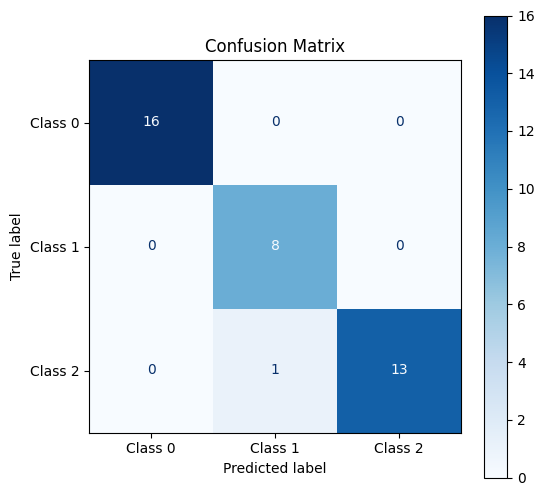

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1', 'Class 2'])
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


**Per-Class Formulas (One-vs-Rest for each class $i$):**

$$\text{Precision}_i = \frac{TP_i}{TP_i + FP_i}$$

$$\text{Recall}_i = \frac{TP_i}{TP_i + FN_i}$$

$$F_{1,i} = \frac{2}{\frac{1}{\text{Precision}_i} + \frac{1}{\text{Recall}_i}} = 2 \times \frac{\text{Precision}_i \times \text{Recall}_i}{\text{Precision}_i + \text{Recall}_i}$$

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1', 'Class 2']))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        16
     Class 1       0.89      1.00      0.94         8
     Class 2       1.00      0.93      0.96        14

    accuracy                           0.97        38
   macro avg       0.96      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



**Averaging Strategies:**

| Strategy | Formula | Use Case |
|----------|---------|----------|
| **Macro** | $\frac{1}{n} \sum_{i=1}^{n} \text{Metric}_i$ | Treats all classes equally |
| **Weighted** | $\frac{\sum_{i=1}^{n} (\text{Metric}_i \times \text{Support}_i)}{\sum_{i=1}^{n} \text{Support}_i}$ | Accounts for class imbalance |
| **Micro** | $\frac{\sum TP_i}{\sum TP_i + \sum FP_i}$ | Global metric across all classes |

$\text{Support}_i$ is number of true instance for class i

**Use Case Guidelines:**
- **Macro averaging**: When all classes are equally important
- **Weighted averaging**: When dealing with class imbalance
- **Micro averaging**: When you care about overall instance-level performance

**Interpretation of Metrics:**
- **Precision (Positive Predictive Value)**: When the model predicts a positive case, how often is it right? 
- **Recall (Sensitivity/True Positive Rate)**: Out of all actual positive cases, how many did the model find? 
- **F1-Score**: The harmonic mean of precision and recall, ranging from 0 to 1, where 1 is perfect and 0 is the worst. It acts as a strict average that penalizes extreme imbalances between precision and recall, meaning both must be high to achieve a high F1-score. 

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Default: returns a single metric (averaged)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-Score: {f1_macro:.4f}")

Macro Precision: 0.9630
Macro Recall: 0.9762
Macro F1-Score: 0.9680


In [ ]:
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")


Weighted Precision: 0.9766
Weighted Recall: 0.9737
Weighted F1-Score: 0.9740


In [ ]:
precision_micro = precision_score(y_test, y_pred, average='micro')
recall_micro = recall_score(y_test, y_pred, average='micro')
f1_micro = f1_score(y_test, y_pred, average='micro')

print(f"\nMicro Precision: {precision_micro:.4f}")
print(f"Micro Recall: {recall_micro:.4f}")
print(f"Micro F1-Score: {f1_micro:.4f}")


Micro Precision: 0.9737
Micro Recall: 0.9737
Micro F1-Score: 0.9737


### 4. ROC (Receiver Operating Characteristic) Curve and AUC (Binary and Multi-Class)

**True Positive Rate (TPR):**
$$\text{Recall} = \text{TPR} = \frac{TP}{TP + FN}$$

**False Positive Rate (FPR):**
$$\text{Fall-Out} = \text{FPR} = \frac{FP}{FP + TN}$$

**ROC Curve:** A plot of TPR vs. FPR at various threshold settings.

In [ ]:
X = iris.data.values
y = iris.target.values
y_new = (y != 0).astype(int)
y_new

X_train, X_test, y_train, y_test = train_test_split(X, y_new, test_size=0.3, random_state=123)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
y_pred = lr_clf.predict(X_test)
y_pred

array([1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1])

In [ ]:
y_test

array([1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1])

In [ ]:
y_score = lr_clf.decision_function(X_test)
y_score

array([ 6.27383774,  7.96591352,  8.22894749,  3.66209313, -4.00703355,
        5.80760294,  5.16974903, -4.07170419, -3.63104329,  4.47042386,
        7.25776597, -4.08056361,  3.35518024,  7.55301137,  9.86756287,
        8.55665209, -3.76918866, -4.48903137,  5.35727757, -3.42457838,
       -3.62296937,  6.47832728, -2.73976456,  6.07066456, -3.5416949 ,
       -2.88179597, -3.13265112,  6.16025947, 10.4666125 , -3.8693995 ,
        9.51544531,  6.5704642 , -3.28251931, -3.74618444,  3.97184988,
        1.91118046,  9.73823988, -3.07856876, -3.93876934,  3.46400399,
        2.56689151, -3.99868546,  8.85495208,  7.45199674,  6.67196374])

In [ ]:
1 / (1 + np.exp(-y_score)) 

array([0.99811857, 0.99965303, 0.99973325, 0.97496418, 0.0178624 ,
       0.99700438, 0.99434615, 0.01676254, 0.025805  , 0.98868698,
       0.99929582, 0.01661714, 0.96627406, 0.99947575, 0.99994817,
       0.99980778, 0.02255052, 0.01110677, 0.99530839, 0.0315361 ,
       0.02600875, 0.99846598, 0.06066732, 0.99769568, 0.02814888,
       0.05306082, 0.04178034, 0.99789274, 0.99997153, 0.02044421,
       0.9999263 , 0.99860081, 0.03617577, 0.02306318, 0.98150978,
       0.87115171, 0.99994102, 0.04399998, 0.01910024, 0.96964604,
       0.92870014, 0.01800944, 0.99985735, 0.99942005, 0.99873569])

In [ ]:
from sklearn.model_selection import cross_val_predict
y_scores = cross_val_predict(lr_clf, X, y_new, cv=3, method="decision_function")

**AUC (Area Under the Curve):** The area under the ROC curve, representing the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance.

**Mathematical Formula:**
$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}^{-1}(t)) dt$$


**Interpretation:**
- AUC = 0.5: Random classifier
- AUC = 1.0: Perfect classifier
- AUC > 0.9: Excellent
- AUC > 0.8: Good
- AUC > 0.7: Fair

**Multi-Class AUC Averaging:**
- **Micro**: Calculate metrics globally from all classes
- **Macro**: Calculate metric for each class, then average
- **Weighted**: Calculate metric for each class, weighted by support

### 5. Precision-Recall Curve (Binary and Multi-Class)

**Definition:** A plot of precision vs. recall at various threshold settings. More informative than ROC for imbalanced datasets.


**Use Case:** More informative than ROC for imbalanced datasets, especially in multi-class settings.


In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_new, y_scores)

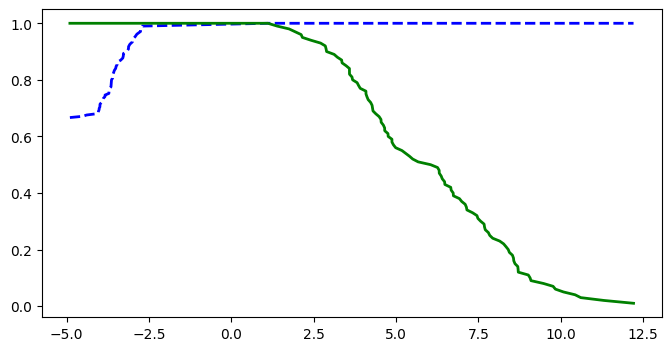

In [ ]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
# plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies Figure 3–5
# idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
# plt.plot(thresholds[idx], precisions[idx], "bo")
# plt.plot(thresholds[idx], recalls[idx], "go")
# plt.axis([-50000, 50000, 0, 1])
# plt.grid()
# plt.xlabel("Threshold")
# plt.legend(loc="center right")

plt.show()

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
cross_val_score(dummy_clf, X_train, y_train, cv=3, scoring="accuracy")

NameError: name 'cross_val_score' is not defined

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

for train_index, test_index in skfolds.split(X_train, y_train):
    clone_clf = clone(lr_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

1.0
0.918918918918919
0.9459459459459459


In [ ]:
from sklearn.preprocessing import TargetEncoder, LabelEncoder
LabelEncoder